In [2094]:
import numpy as np
import random
import matplotlib.pyplot  as plt
import scipy.stats as sci
from math import exp
from scipy.special import comb

In [2095]:
count = 25

In [2096]:
def bootstrap(n, sample):
    bootstrap_sample = []
    for _ in range (n):
        idx = np.random.randint(0, len(sample), len(sample))
        bootstrap_sample.append(sample[idx])
    return np.array(bootstrap_sample)

### Генерация выборки

In [2097]:
sample = np.array([random.expovariate(1) for _ in range (count)])

print(f'Выборка: {sample}')

Выборка: [0.01385708 0.39938528 5.01208011 0.47633004 1.26257124 2.43158813
 2.05145227 1.4552669  3.77942062 1.45649979 0.23555971 1.54026055
 0.48623643 0.37180737 1.47514956 1.86947932 0.74272776 0.7334726
 1.78234816 0.26309606 0.9706254  0.54802387 1.4543006  1.03688799
 0.52492512]


### а)

In [2098]:
unique_elems = np.unique_counts(sample)

if np.max(unique_elems.counts) == 1:
    print (f'Мода: все элементы')
else:
    print(f'Мода: {unique_elems.values[unique_elems.counts.argmax()]}')


mu3 = np.mean((sample - np.mean(sample))**3)
mu2 = np.mean((sample - np.mean(sample))**2)
print (f'Коэфициент ассиметрии: {mu3/(mu2**(3/2))}')

print(f'Медиана: {np.sort(sample)[13]}')
print(f'Размах: {sample.max() - sample.min()}')

Мода: все элементы
Коэфициент ассиметрии: 1.7295355915417912
Медиана: 1.2625712375982616
Размах: 4.998223031315793


### b)

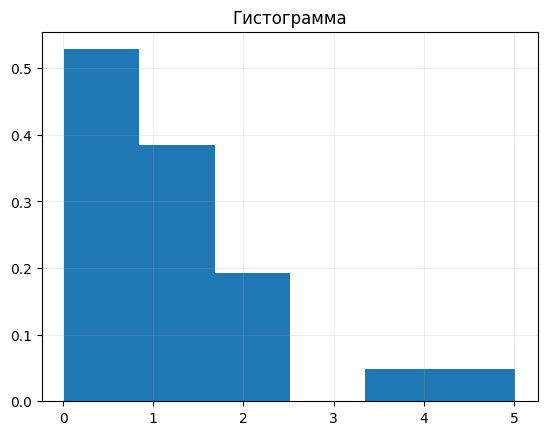

In [2099]:
plt.hist(sample, density=True, bins='sturges')

plt.grid(alpha=0.2)
plt.title('Гистограмма')
plt.show()

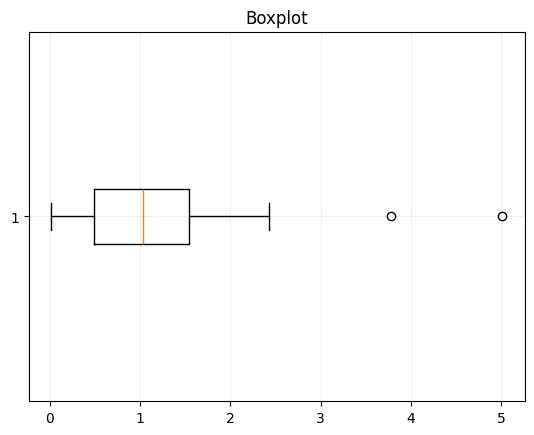

In [2100]:
plt.boxplot(sample, vert=False)

plt.grid(alpha=0.2)
plt.title('Boxplot')
plt.show()

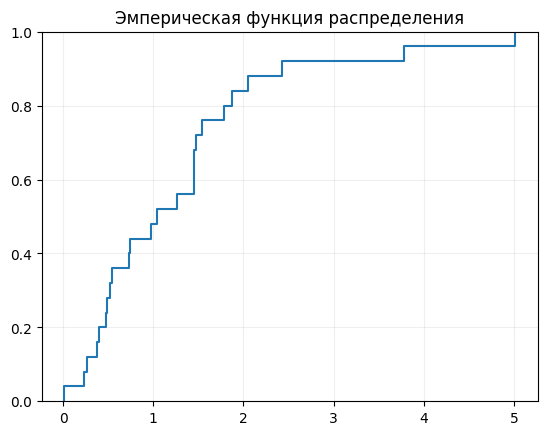

In [2101]:
plt.ecdf(sample)

plt.grid(alpha=0.2)
plt.title('Эмперическая функция распределения')

plt.show()

### c)

In [2102]:
bootstrap_samples = bootstrap(100000, sample)

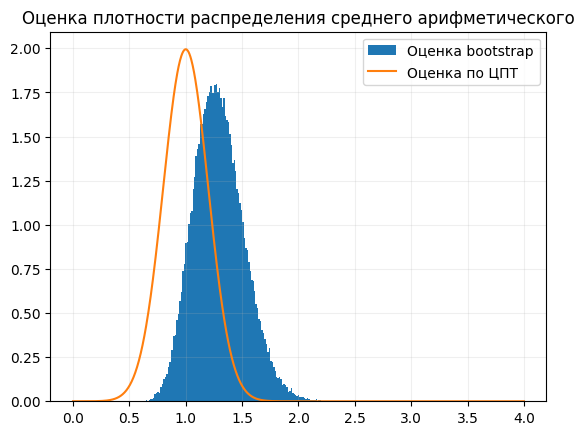

In [2103]:
bootstrap_mean = np.mean(bootstrap_samples, axis=1)

plt.hist(bootstrap_mean, bins='auto', density=True, label='Оценка bootstrap')

x = np.linspace(0, 4, 1000)
y = sci.norm.pdf(x, loc=1, scale=1/5)

plt.plot(x, y, label='Оценка по ЦПТ')

plt.legend()
plt.grid(alpha=0.2)
plt.title('Оценка плотности распределения среднего арифметического')
plt.show()


### d)

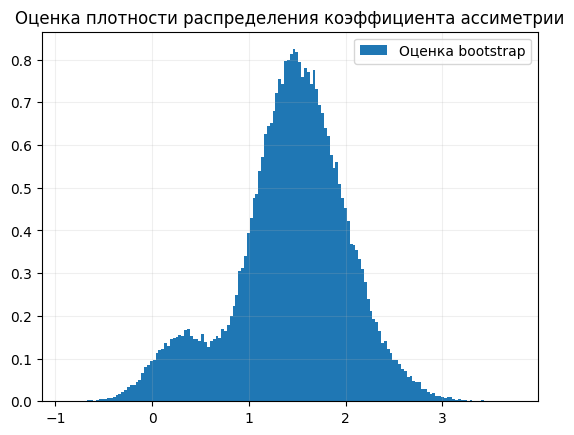

In [2104]:
asymmetry_coeff = sci.skew(bootstrap_samples, axis=1)

plt.hist(asymmetry_coeff, bins='auto', density=True, label='Оценка bootstrap')

plt.grid(alpha=0.2)
plt.legend()
plt.title('Оценка плотности распределения коэффициента ассиметрии')
plt.show()

In [2105]:
hist, bins = np.histogram(asymmetry_coeff, bins='auto', density=True)
dx = np.diff(bins)

integration_mask = bins[:-1] < 1

print (f'Вероятность коэффициент ассиметрии < 1 = {np.sum(hist[integration_mask] * dx[integration_mask])}') 

Вероятность коэффициент ассиметрии < 1 = 0.19477999999999998


### e)

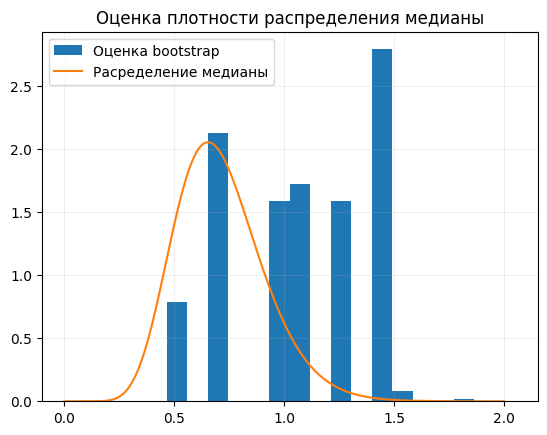

In [2106]:
mediana = np.median(bootstrap_samples, axis=1)

plt.hist(mediana, bins='sturges', density=True, label='Оценка bootstrap')

x = np.linspace(0, 2, 1000)
i = np.arange(13,26)
y = np.sum(
    comb(25, i)[:, None] * (
        i[:, None] * (1 - np.exp(-x))[None, :]**(i[:, None] - 1)
        * np.exp(-x)[None, :] * np.exp(-x)[None, :]**(25 - i[:, None])
        -
        (25 - i)[:, None] * (1 - np.exp(-x))[None, :]**i[:, None]
        * np.exp(-x)[None, :]**(24 - i[:, None]) * np.exp(-x)[None, :]
    ),
    axis=0
)

plt.plot(x, y, label='Расределение медианы')

plt.legend()
plt.grid(alpha=0.2)
plt.title('Оценка плотности распределения медианы')
plt.show()